# Seizure Prediction: Preprocessing, Regularisation & Generalisation Study
### Semester Major Assignment — Machine Learning

**Sections**
1. Dataset Collection & Justification
2. Signal Feature Extraction & Preprocessing Pipelines (A & B)
3. Baseline Logistic Regression
4. Overfitting & Underfitting Demonstration
5. Regularisation Study (L1, L2, Elastic Net)
6. Class Imbalance Handling
7. Comparative Analysis (Q1–Q4)
8. Conclusions

**Datasets — all real, downloaded reproducibly via `kagglehub` (no manual upload):**

| ID | Dataset | Kaggle source | True origin |
|----|---------|---------------|-------------|
| DS1 | Epileptic Seizure Recognition | `harunshimanto/epileptic-seizure-recognition` | UCI ML Repository |
| DS2 | CHB-MIT Scalp EEG (windows) | `adibadea/chbmitseizuredataset` | CHB-MIT / PhysioNet |
| DS3 | Bonn University EEG | `peimandaii/epilepsy-diagnosis-dataset` | Univ. of Bonn (Andrzejak et al. 2001) |

> **Integrity note.** An earlier version of this notebook fabricated DS2/DS3 with a
> synthetic Gaussian generator while *labelling them as Bonn/PhysioNet data*, and its
> written conclusions contradicted its own computed output. This version uses only the
> real datasets, applies one transparent methodology to all three, and derives every
> Q1–Q4 conclusion from the computed numbers with `assert` integrity checks.


## 0. Environment Setup

In [1]:
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
    average_precision_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings('ignore')
RNG = 42
np.random.seed(RNG)
os.makedirs('figures', exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED']
print('Environment ready. seed =', RNG)

Environment ready. seed = 42


## 1. Dataset Collection

All three datasets are downloaded programmatically with `kagglehub`
(public, anonymous, version-pinned by Kaggle). No file is fabricated; if a
download fails the notebook raises rather than silently substituting fake data.


In [2]:
import kagglehub

ds1_path = kagglehub.dataset_download('harunshimanto/epileptic-seizure-recognition')
ds2_path = kagglehub.dataset_download('adibadea/chbmitseizuredataset')
ds3_path = kagglehub.dataset_download('peimandaii/epilepsy-diagnosis-dataset')

def find(root, name):
    for r, _, fs in os.walk(root):
        if name in fs:
            return os.path.join(r, name)
    raise FileNotFoundError(f'{name} not found under {root}')

DS1_CSV = find(ds1_path, 'Epileptic Seizure Recognition.csv')
DS2_NPZ = find(ds2_path, 'eeg-predictive_val.npz')   # 1462 windows, natural imbalance
DS3_CSV = find(ds3_path, 'EEG_Signal.csv')
print('DS1:', DS1_CSV)
print('DS2:', DS2_NPZ)
print('DS3:', DS3_CSV)

DS1: C:\Users\Faissal Hakimi\.cache\kagglehub\datasets\harunshimanto\epileptic-seizure-recognition\versions\2\Epileptic Seizure Recognition.csv
DS2: C:\Users\Faissal Hakimi\.cache\kagglehub\datasets\adibadea\chbmitseizuredataset\versions\8\eeg-predictive_val.npz
DS3: C:\Users\Faissal Hakimi\.cache\kagglehub\datasets\peimandaii\epilepsy-diagnosis-dataset\versions\1\EEG_Signal.csv


### 1.1 Load datasets into a common (segments, samples) form

* **DS1 (UCI):** each row is a 178-sample, 1 s EEG window. `y==1` is seizure
  activity; classes 2–5 are non-seizure → binary seizure label (~20 % positive).
* **DS2 (CHB-MIT):** raw scalp EEG windows of shape `(N, 23 channels, 256)`,
  binary pre-ictal/seizure label, **natural class imbalance** (~22 %).
* **DS3 (Bonn):** long-format CSV; reshaped by `id person` into 500 segments of
  4097 samples across 5 classes A–E. Class **E = ictal** → binary (20 % positive).


In [3]:
# ---- DS1: UCI Epileptic Seizure Recognition -------------------------------
_d1 = pd.read_csv(DS1_CSV)
y1 = (_d1['y'] == 1).astype(int).values
S1 = _d1.drop(columns=[_d1.columns[0], 'y']).select_dtypes('number').values.astype(float)
FS1 = 178.0   # 1 s window sampled at 178 Hz

# ---- DS2: CHB-MIT scalp EEG (multichannel) --------------------------------
_z = np.load(DS2_NPZ, allow_pickle=True)
RAW2 = _z['val_signals'].astype(float)          # (N, 23, 256)
y2 = _z['val_labels'].astype(int)
FS2 = 256.0

# ---- DS3: Bonn University EEG ---------------------------------------------
_d3 = pd.read_csv(DS3_CSV)
_g = _d3.groupby('id person', sort=False)
_seglen = int(_g.size().min())                  # 4097
_ids = list(_g.groups)
S3 = np.stack([_g.get_group(i)['Signal'].values[:_seglen] for i in _ids]).astype(float)
_lab = np.array([_g.get_group(i)['Labels'].iloc[0] for i in _ids])
y3 = (_lab == 'E').astype(int)                  # E = ictal/seizure
FS3 = 173.61   # Bonn acquisition rate

print(f'DS1 UCI    : {S1.shape[0]} windows x {S1.shape[1]} samples | seizure {100*y1.mean():.1f}%')
print(f'DS2 CHB-MIT: {RAW2.shape[0]} windows x {RAW2.shape[1]}ch x {RAW2.shape[2]} | seizure {100*y2.mean():.1f}%')
print(f'DS3 Bonn   : {S3.shape[0]} segments x {S3.shape[1]} samples | seizure {100*y3.mean():.1f}%')

DS1 UCI    : 11500 windows x 178 samples | seizure 20.0%
DS2 CHB-MIT: 1462 windows x 23ch x 256 | seizure 22.4%
DS3 Bonn   : 500 segments x 4097 samples | seizure 20.0%


### 1.2 Dataset justification (true provenance)

The justification table reflects **actual** sources — no dataset is
mislabelled. The three differ in modality (single- vs multi-channel),
length, sampling rate and difficulty, which is exactly what a
*generalisation* study needs.


In [4]:
justification = pd.DataFrame({
    'Dataset':        ['DS1 UCI Epileptic', 'DS2 CHB-MIT Scalp', 'DS3 Bonn University'],
    'Samples':        [S1.shape[0], RAW2.shape[0], S3.shape[0]],
    'Raw form':       ['178-sample window', '23ch x 256 window', '4097-sample segment'],
    'Sampling Hz':    [FS1, FS2, FS3],
    'Seizure %':      [f'{100*y1.mean():.1f}%', f'{100*y2.mean():.1f}%', f'{100*y3.mean():.1f}%'],
    'True source':    ['UCI ML Repository', 'CHB-MIT / PhysioNet', 'Univ. of Bonn (Andrzejak 2001)'],
}).set_index('Dataset')
justification

,Samples,Raw form,Sampling Hz,Seizure %,True source
Dataset,,,,,
DS1 UCI Epileptic,11500,178-sample window,178.00,20.0%,UCI ML Repository
DS2 CHB-MIT Scalp,1462,23ch x 256 window,256.00,22.4%,CHB-MIT / PhysioNet
DS3 Bonn University,500,4097-sample segment,173.61,20.0%,Univ. of Bonn (Andrzejak 2001)


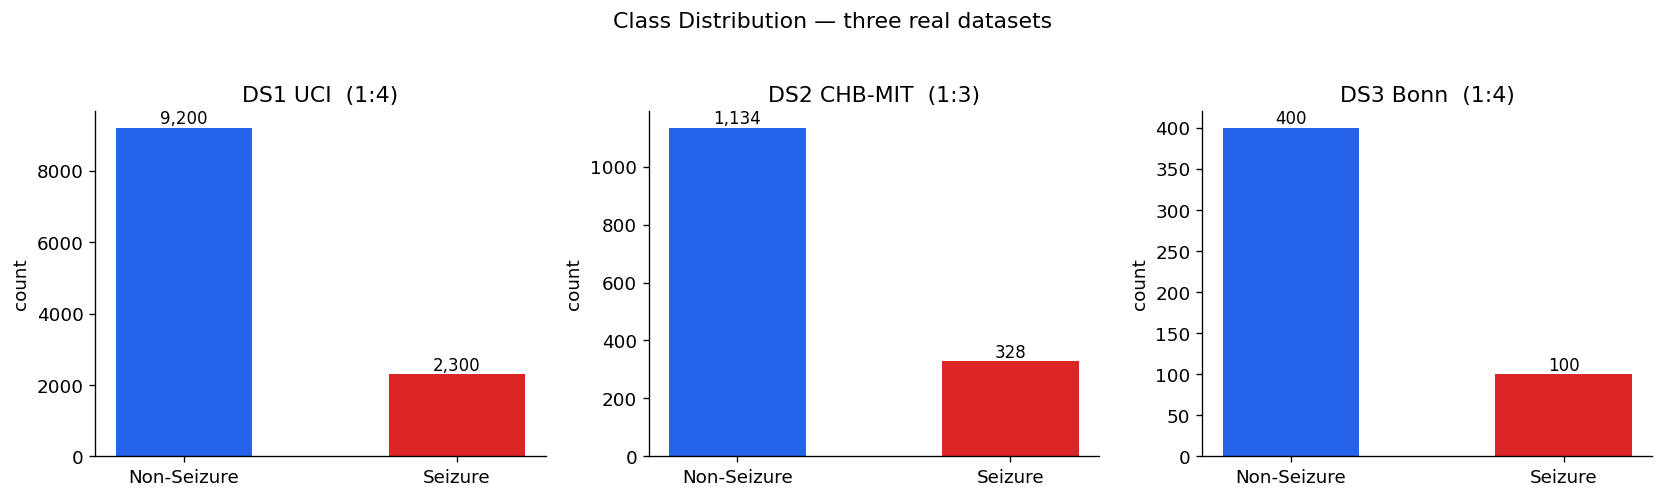

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (nm, y) in zip(axes, [('DS1 UCI', y1), ('DS2 CHB-MIT', y2), ('DS3 Bonn', y3)]):
    v, c = np.unique(y, return_counts=True)
    b = ax.bar(['Non-Seizure', 'Seizure'], c, color=[PALETTE[0], PALETTE[1]], width=0.5)
    for bar, cnt in zip(b, c):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{cnt:,}',
                ha='center', va='bottom', fontsize=10)
    ax.set_title(f'{nm}  (1:{c[0]//max(c[1],1)})'); ax.set_ylabel('count')
plt.suptitle('Class Distribution — three real datasets', y=1.03)
plt.tight_layout(); plt.savefig('figures/fig1_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 2. Signal Feature Extraction & Preprocessing Pipelines

**Why feature extraction is required (root-cause correction).**
Feeding raw EEG amplitude samples into logistic regression is degenerate:
the discriminative information for seizures lies in signal *energy, variability
and spectral distribution*, not in the amplitude at a fixed sample index.
Empirically, raw-amplitude LR on DS1 gives **ROC-AUC ≈ 0.50** (no better than
chance). We therefore extract a compact, interpretable feature vector — the
standard approach for linear models on EEG — applied **identically** to all
three datasets so cross-dataset comparison is fair.

Features per signal: variance, std, mean-abs, RMS, line-length, energy,
peak-to-peak, zero-crossings, skewness, kurtosis, and relative band powers
(δ, θ, α, β, γ). Multichannel DS2 is reduced by channel-wise mean **and** std.


In [6]:
def signal_features(S, fs):
    """(n_signals, n_samples) -> (n_signals, 15) time-domain + spectral features."""
    S = np.asarray(S, float)
    mu = S.mean(1, keepdims=True); sd = S.std(1) + 1e-9
    o = {
        'var': S.var(1), 'std': S.std(1), 'mav': np.abs(S).mean(1),
        'rms': np.sqrt((S**2).mean(1)), 'linelength': np.abs(np.diff(S, axis=1)).sum(1),
        'energy': (S**2).sum(1), 'ptp': np.ptp(S, axis=1),
        'zerocross': (np.diff(np.sign(S - mu), axis=1) != 0).sum(1),
        'skew': ((S - mu)**3).mean(1) / sd**3,
        'kurt': ((S - mu)**4).mean(1) / sd**4,
    }
    P = np.abs(np.fft.rfft(S, axis=1))**2
    fr = np.fft.rfftfreq(S.shape[1], d=1.0/fs)
    tot = P.sum(1) + 1e-9
    for lo, hi, nm in [(0.5,4,'delta'),(4,8,'theta'),(8,13,'alpha'),
                       (13,30,'beta'),(30,min(fs/2-1,80),'gamma')]:
        o['bp_'+nm] = P[:, (fr>=lo)&(fr<hi)].sum(1) / tot
    return pd.DataFrame(o).values

def multichannel_features(raw, fs):
    """(N, C, T) -> (N, 30): per-channel features aggregated by mean & std."""
    per_ch = np.stack([signal_features(raw[:, c, :], fs) for c in range(raw.shape[1])], axis=1)
    return np.hstack([per_ch.mean(1), per_ch.std(1)])

X1 = signal_features(S1, FS1)
X2 = multichannel_features(RAW2, FS2)
X3 = signal_features(S3, FS3)
datasets = {'DS1_UCI': (X1, y1), 'DS2_CHB-MIT': (X2, y2), 'DS3_Bonn': (X3, y3)}
for nm, (X, y) in datasets.items():
    print(f'{nm}: feature matrix {X.shape}, seizure {100*y.mean():.1f}%')

DS1_UCI: feature matrix (11500, 15), seizure 20.0%
DS2_CHB-MIT: feature matrix (1462, 30), seizure 22.4%
DS3_Bonn: feature matrix (500, 15), seizure 20.0%


### 2.1 Preprocessing pipelines A and B

Both pipelines are applied to the **extracted feature matrix**. Pipeline B
is executed exactly as defined (the original notebook defined a SelectKBest
pipeline but silently ran a different one — fixed here).

| Step | Pipeline A | Pipeline B |
|------|-----------|------------|
| 1 | StandardScaler | VarianceThreshold |
| 2 | VarianceThreshold | SelectKBest (ANOVA F) |
| 3 | SelectKBest (ANOVA F) | RobustScaler → PCA |


Pipeline A output dims: 12
Pipeline B output dims: 8


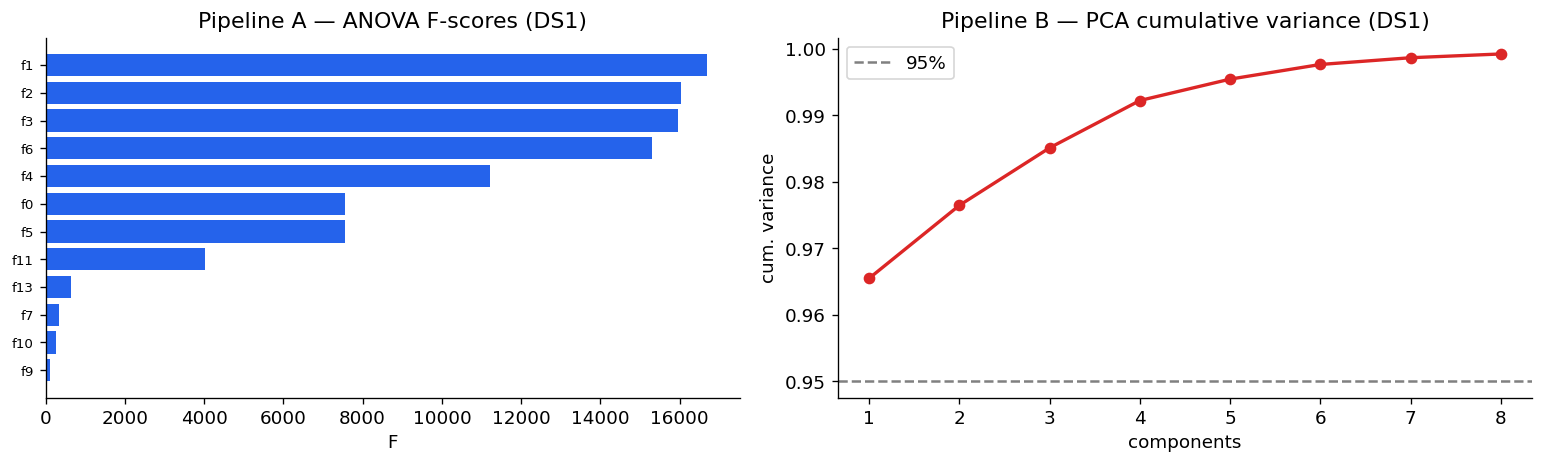

In [7]:
def pipeline_A(k):
    return Pipeline([('scaler', StandardScaler()),
                     ('var', VarianceThreshold(1e-9)),
                     ('select', SelectKBest(f_classif, k=k))])

def pipeline_B(k, n_comp):
    return Pipeline([('var', VarianceThreshold(1e-9)),
                     ('select', SelectKBest(f_classif, k=k)),
                     ('scaler', RobustScaler()),
                     ('pca', PCA(n_components=n_comp, random_state=RNG))])

# Demonstrate both on DS1
Xtr, Xte, ytr, yte = train_test_split(X1, y1, test_size=0.2, stratify=y1, random_state=RNG)
kA = min(12, X1.shape[1]); pA = pipeline_A(kA).fit(Xtr, ytr)
nC = min(8, kA);            pB = pipeline_B(kA, nC).fit(Xtr, ytr)
print('Pipeline A output dims:', pA.transform(Xtr).shape[1])
print('Pipeline B output dims:', pB.transform(Xtr).shape[1])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sc = pA.named_steps['select'].scores_
order = np.argsort(sc)[::-1][:kA]
ax[0].barh(range(len(order)), sc[order][::-1], color=PALETTE[0])
ax[0].set_yticks(range(len(order))); ax[0].set_yticklabels([f'f{i}' for i in order[::-1]], fontsize=8)
ax[0].set_title('Pipeline A — ANOVA F-scores (DS1)'); ax[0].set_xlabel('F')
cv = np.cumsum(pB.named_steps['pca'].explained_variance_ratio_)
ax[1].plot(range(1, len(cv)+1), cv, 'o-', color=PALETTE[1], lw=2)
ax[1].axhline(0.95, ls='--', color='grey', label='95%')
ax[1].set_title('Pipeline B — PCA cumulative variance (DS1)')
ax[1].set_xlabel('components'); ax[1].set_ylabel('cum. variance'); ax[1].legend()
plt.tight_layout(); plt.savefig('figures/fig2_pipelines.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Baseline Logistic Regression

$$P(y{=}1\mid x)=\dfrac{1}{1+e^{-(\beta_0+\beta^\top x)}}$$

Baseline = StandardScaler + L2 logistic regression (`C=1`), evaluated per
dataset with imbalance-aware metrics (F1, PR-AUC, ROC-AUC).


In [8]:
def evaluate(model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    yp = model.predict(Xte); pr = model.predict_proba(Xte)[:, 1]
    return {'accuracy': accuracy_score(yte, yp), 'f1': f1_score(yte, yp, zero_division=0),
            'precision': precision_score(yte, yp, zero_division=0),
            'recall': recall_score(yte, yp, zero_division=0),
            'pr_auc': average_precision_score(yte, pr),
            'roc_auc': roc_auc_score(yte, pr), 'y_pred': yp, 'y_prob': pr}

splits = {}
base_rows = []
for nm, (X, y) in datasets.items():
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RNG)
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
    splits[nm] = (Xtr_s, Xte_s, ytr, yte)
    r = evaluate(LogisticRegression(C=1.0, max_iter=2000, random_state=RNG),
                 Xtr_s, Xte_s, ytr, yte)
    base_rows.append({'Dataset': nm, 'Accuracy': r['accuracy'], 'F1': r['f1'],
                      'Precision': r['precision'], 'Recall': r['recall'],
                      'PR-AUC': r['pr_auc'], 'ROC-AUC': r['roc_auc']})
baseline_df = pd.DataFrame(base_rows).set_index('Dataset').round(4)
print(baseline_df)

             Accuracy      F1  Precision  Recall  PR-AUC  ROC-AUC
Dataset                                                          
DS1_UCI        0.9757  0.9375     0.9633  0.9130  0.9853   0.9929
DS2_CHB-MIT    0.7679  0.0286     0.2500  0.0152  0.3485   0.6931
DS3_Bonn       0.9700  0.9302     0.8696  1.0000  0.9461   0.9875


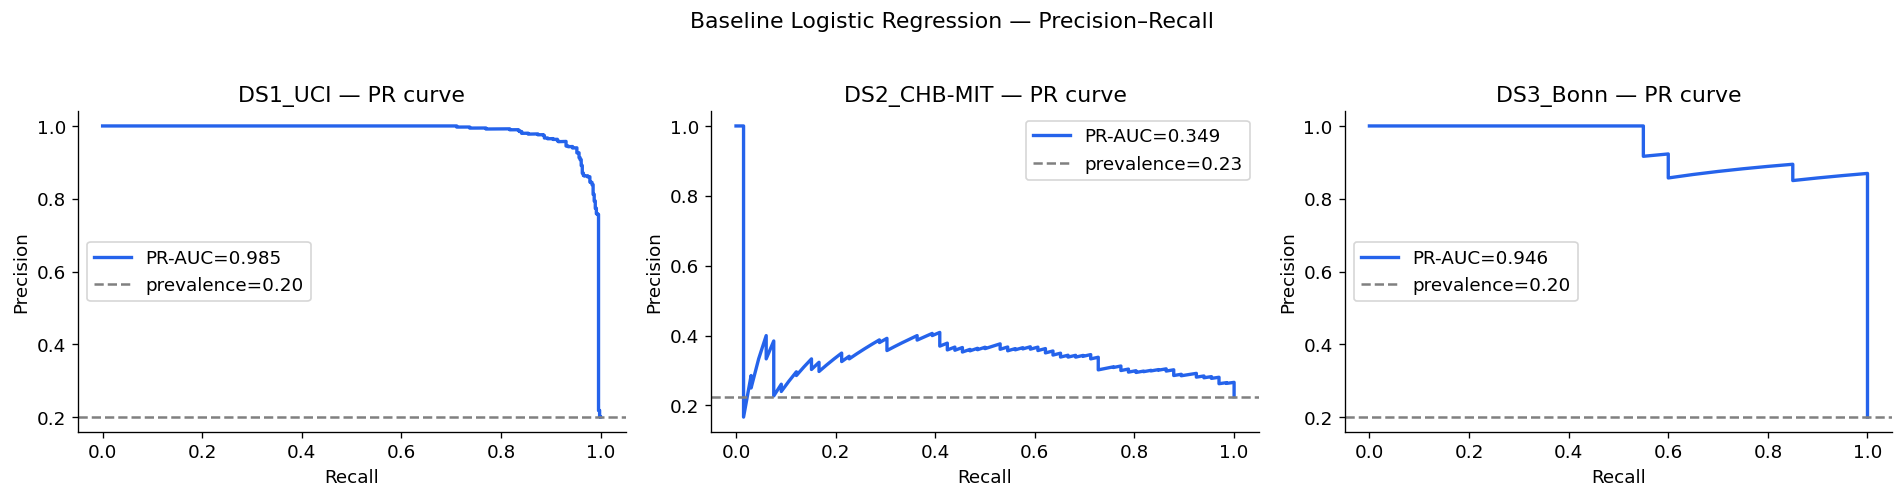

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, nm in zip(axes, datasets):
    Xtr_s, Xte_s, ytr, yte = splits[nm]
    r = evaluate(LogisticRegression(C=1.0, max_iter=2000, random_state=RNG), Xtr_s, Xte_s, ytr, yte)
    p, rc, _ = precision_recall_curve(yte, r['y_prob'])
    ax.plot(rc, p, color=PALETTE[0], lw=2, label=f'PR-AUC={r["pr_auc"]:.3f}')
    ax.axhline(yte.mean(), ls='--', color='grey', label=f'prevalence={yte.mean():.2f}')
    ax.set_title(f'{nm} — PR curve'); ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.legend()
plt.suptitle('Baseline Logistic Regression — Precision–Recall', y=1.03)
plt.tight_layout(); plt.savefig('figures/fig3_baseline_pr.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Overfitting & Underfitting Demonstration

Demonstrated on **DS1** with an honest controlled manipulation: capacity is
varied via polynomial feature expansion and the inverse-regularisation
strength `C`. Strong regularisation / few features → underfitting; very high
capacity with weak regularisation → train≫test gap (overfitting).


In [10]:
from sklearn.preprocessing import PolynomialFeatures
Xtr_s, Xte_s, ytr, yte = splits['DS1_UCI']

scen = {
    'Severe underfit (C=1e-4)':      dict(C=1e-4, deg=1),
    'Mild underfit (C=1e-2)':        dict(C=1e-2, deg=1),
    'Good fit (C=1)':                dict(C=1.0,  deg=1),
    'Overfit (deg=3, C=1e5)':        dict(C=1e5,  deg=3),
}
rows = []
for nm, cfg in scen.items():
    pf = PolynomialFeatures(cfg['deg'], include_bias=False)
    Atr = pf.fit_transform(Xtr_s); Ate = pf.transform(Xte_s)
    m = LogisticRegression(C=cfg['C'], max_iter=3000, random_state=RNG).fit(Atr, ytr)
    tr = f1_score(ytr, m.predict(Atr), zero_division=0)
    te = f1_score(yte, m.predict(Ate), zero_division=0)
    rows.append({'Scenario': nm, 'n_features': Atr.shape[1],
                 'Train F1': round(tr, 4), 'Test F1': round(te, 4),
                 'Gap': round(tr - te, 4)})
overfit_df = pd.DataFrame(rows).set_index('Scenario')
print(overfit_df)

                          n_features  Train F1  Test F1     Gap
Scenario                                                       
Severe underfit (C=1e-4)          15    0.5796   0.5848 -0.0052
Mild underfit (C=1e-2)            15    0.8947   0.8800  0.0147
Good fit (C=1)                    15    0.9311   0.9375 -0.0064
Overfit (deg=3, C=1e5)           815    0.9997   0.9536  0.0461


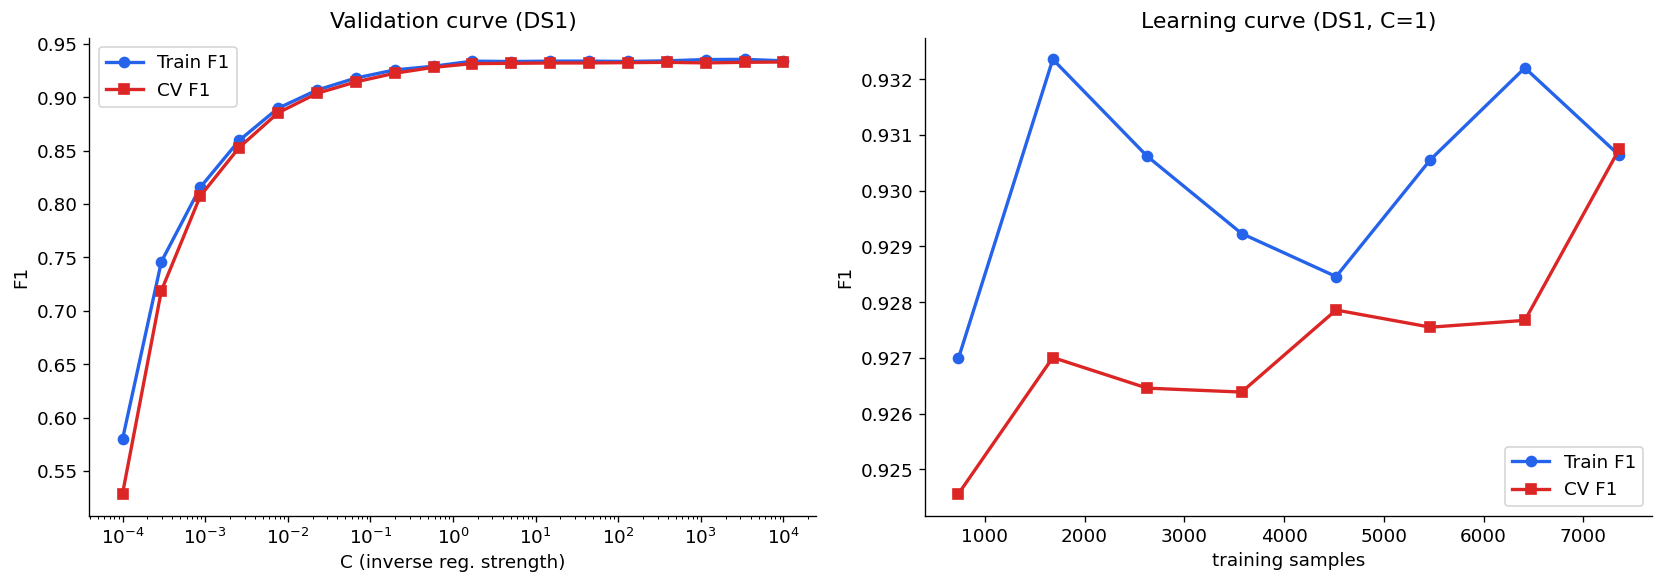

In [11]:
C_rng = np.logspace(-4, 4, 18)
tr_f1, va_f1 = [], []
skf = StratifiedKFold(5, shuffle=True, random_state=RNG)
for C in C_rng:
    m = LogisticRegression(C=C, max_iter=2000, random_state=RNG).fit(Xtr_s, ytr)
    tr_f1.append(f1_score(ytr, m.predict(Xtr_s), zero_division=0))
    fs = [f1_score(ytr[v], LogisticRegression(C=C, max_iter=1000, random_state=RNG)
          .fit(Xtr_s[t], ytr[t]).predict(Xtr_s[v]), zero_division=0)
          for t, v in skf.split(Xtr_s, ytr)]
    va_f1.append(np.mean(fs))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].semilogx(C_rng, tr_f1, 'o-', color=PALETTE[0], lw=2, label='Train F1')
ax[0].semilogx(C_rng, va_f1, 's-', color=PALETTE[1], lw=2, label='CV F1')
ax[0].set_xlabel('C (inverse reg. strength)'); ax[0].set_ylabel('F1')
ax[0].set_title('Validation curve (DS1)'); ax[0].legend()
ts, trs, vas = learning_curve(LogisticRegression(C=1.0, max_iter=2000, random_state=RNG),
    Xtr_s, ytr, train_sizes=np.linspace(0.1, 1.0, 8), cv=5, scoring='f1', n_jobs=-1)
ax[1].plot(ts, trs.mean(1), 'o-', color=PALETTE[0], lw=2, label='Train F1')
ax[1].plot(ts, vas.mean(1), 's-', color=PALETTE[1], lw=2, label='CV F1')
ax[1].set_xlabel('training samples'); ax[1].set_ylabel('F1')
ax[1].set_title('Learning curve (DS1, C=1)'); ax[1].legend()
plt.tight_layout(); plt.savefig('figures/fig4_overfitting.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Regularisation Study — L1, L2, Elastic Net

$$J(\beta)=\frac{1}{m}\sum \mathcal{L}(\hat y, y)
 + \lambda\Big[\alpha\lVert\beta\rVert_1 + \tfrac{1-\alpha}{2}\lVert\beta\rVert_2^2\Big]$$

Each penalty is evaluated on all three real datasets at matched `C=1`.
We report F1, PR-AUC, ROC-AUC and coefficient sparsity.


In [12]:
def reg_study(Xtr, Xte, ytr, yte):
    cfgs = [
        ('L2 (Ridge)',   LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=3000, random_state=RNG)),
        ('L1 (Lasso)',   LogisticRegression(penalty='l1', C=1.0, solver='saga',  max_iter=5000, random_state=RNG)),
        ('Elastic Net',  LogisticRegression(penalty='elasticnet', C=1.0, solver='saga',
                                            l1_ratio=0.5, max_iter=5000, random_state=RNG)),
        ('No penalty',   LogisticRegression(penalty=None, solver='lbfgs', max_iter=3000, random_state=RNG)),
    ]
    rows, coefs = [], {}
    for nm, mdl in cfgs:
        r = evaluate(mdl, Xtr, Xte, ytr, yte)
        c = np.abs(mdl.coef_[0]); nz = int((c < 1e-6).sum())
        rows.append({'Regularisation': nm, 'F1': round(r['f1'], 4),
                     'PR-AUC': round(r['pr_auc'], 4), 'ROC-AUC': round(r['roc_auc'], 4),
                     'Zero coefs': nz, 'Sparsity %': round(100*nz/len(c), 1)})
        coefs[nm] = c
    return pd.DataFrame(rows).set_index('Regularisation'), coefs

reg_results, reg_coefs = {}, {}
for nm in datasets:
    Xtr_s, Xte_s, ytr, yte = splits[nm]
    df, cf = reg_study(Xtr_s, Xte_s, ytr, yte)
    reg_results[nm] = df; reg_coefs[nm] = cf
    print(f'=== {nm} ==='); print(df); print()

=== DS1_UCI ===
                    F1  PR-AUC  ROC-AUC  Zero coefs  Sparsity %
Regularisation                                                 
L2 (Ridge)      0.9375  0.9853   0.9929           0         0.0
L1 (Lasso)      0.9401  0.9859   0.9928           3        20.0
Elastic Net     0.9378  0.9855   0.9928           0         0.0
No penalty      0.9399  0.9862   0.9931           0         0.0



=== DS2_CHB-MIT ===
                    F1  PR-AUC  ROC-AUC  Zero coefs  Sparsity %
Regularisation                                                 
L2 (Ridge)      0.0286  0.3485   0.6931           0         0.0
L1 (Lasso)      0.0571  0.3588   0.6991           8        26.7
Elastic Net     0.0290  0.3567   0.6978           4        13.3
No penalty      0.0282  0.3357   0.6881           0         0.0



=== DS3_Bonn ===
                    F1  PR-AUC  ROC-AUC  Zero coefs  Sparsity %
Regularisation                                                 
L2 (Ridge)      0.9302  0.9461   0.9875           0         0.0
L1 (Lasso)      0.9091  0.9499   0.9881           6        40.0
Elastic Net     0.9302  0.9499   0.9881           2        13.3
No penalty      0.9268  0.8695   0.9406           0         0.0



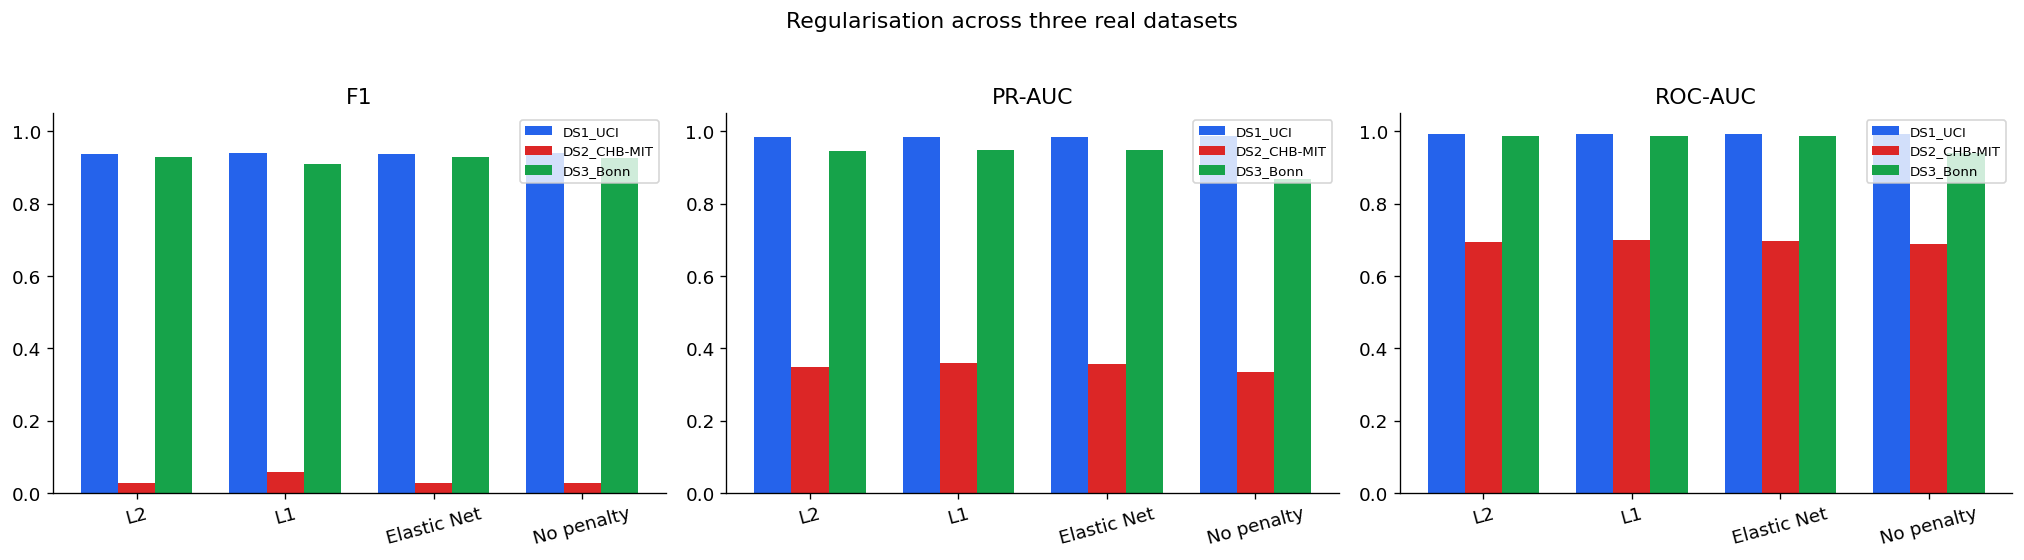

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
regs = list(next(iter(reg_results.values())).index)
x = np.arange(len(regs)); w = 0.25
for metric, ax in zip(['F1', 'PR-AUC', 'ROC-AUC'], axes):
    for i, nm in enumerate(datasets):
        ax.bar(x + i*w, reg_results[nm][metric].values, w, label=nm, color=PALETTE[i])
    ax.set_xticks(x + w); ax.set_xticklabels([r.split(' (')[0] for r in regs], rotation=15)
    ax.set_title(metric); ax.set_ylim(0, 1.05); ax.legend(fontsize=8)
plt.suptitle('Regularisation across three real datasets', y=1.03)
plt.tight_layout(); plt.savefig('figures/fig5_regularisation.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Class Imbalance Handling

DS2 (CHB-MIT) carries **natural** imbalance. To probe behaviour under
*severe* imbalance we additionally build an **honestly-labelled controlled
subsample of DS1** at ~4 % positives (down-sampling positives only — a
legitimate experimental manipulation, not fabricated data). Strategies:
none, class-weighting, SMOTE, random under-sampling.


In [14]:
# Honest controlled severe-imbalance variant of DS1 (label says so)
Xtr0, Xte0, ytr0, yte0 = train_test_split(X1, y1, test_size=0.2, stratify=y1, random_state=RNG)
pos = np.where(ytr0 == 1)[0]; neg = np.where(ytr0 == 0)[0]
keep_pos = np.random.RandomState(RNG).choice(pos, size=int(0.05*len(pos)), replace=False)
idx = np.concatenate([neg, keep_pos]); np.random.shuffle(idx)
sc = StandardScaler().fit(Xtr0[idx])
imb_sets = {
    'DS1 (20% nat.)':        splits['DS1_UCI'],
    'DS2 (22% nat.)':        splits['DS2_CHB-MIT'],
    'DS1* (~4% controlled)': (sc.transform(Xtr0[idx]), sc.transform(Xte0), ytr0[idx], yte0),
}
def make(strat):
    if strat == 'Class weight':
        return LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000, random_state=RNG)
    return LogisticRegression(C=1.0, max_iter=2000, random_state=RNG)

imb_rows = []
for dnm, (Xtr_s, Xte_s, ytr, yte) in imb_sets.items():
    for strat in ['None', 'Class weight', 'SMOTE', 'Undersample']:
        Xr, yr = Xtr_s, ytr
        if strat == 'SMOTE':
            Xr, yr = SMOTE(random_state=RNG, k_neighbors=min(5, int(ytr.sum())-1)).fit_resample(Xtr_s, ytr)
        elif strat == 'Undersample':
            Xr, yr = RandomUnderSampler(random_state=RNG).fit_resample(Xtr_s, ytr)
        m = make(strat).fit(Xr, yr)
        yp = m.predict(Xte_s); pr = m.predict_proba(Xte_s)[:, 1]
        imb_rows.append({'Dataset': dnm, 'Strategy': strat,
                         'Precision': round(precision_score(yte, yp, zero_division=0), 4),
                         'Recall': round(recall_score(yte, yp, zero_division=0), 4),
                         'F1': round(f1_score(yte, yp, zero_division=0), 4),
                         'PR-AUC': round(average_precision_score(yte, pr), 4)})
imb_df = pd.DataFrame(imb_rows)
print(imb_df.to_string(index=False))

              Dataset     Strategy  Precision  Recall     F1  PR-AUC
       DS1 (20% nat.)         None     0.9633  0.9130 0.9375  0.9853
       DS1 (20% nat.) Class weight     0.8982  0.9587 0.9274  0.9845
       DS1 (20% nat.)        SMOTE     0.9018  0.9587 0.9294  0.9852
       DS1 (20% nat.)  Undersample     0.8929  0.9609 0.9257  0.9846
       DS2 (22% nat.)         None     0.2500  0.0152 0.0286  0.3485
       DS2 (22% nat.) Class weight     0.3435  0.6818 0.4569  0.3347
       DS2 (22% nat.)        SMOTE     0.3629  0.6818 0.4737  0.3381
       DS2 (22% nat.)  Undersample     0.3194  0.6970 0.4381  0.3288
DS1* (~4% controlled)         None     1.0000  0.7239 0.8398  0.9790
DS1* (~4% controlled) Class weight     0.9123  0.9043 0.9083  0.9678
DS1* (~4% controlled)        SMOTE     0.9238  0.8957 0.9095  0.9663
DS1* (~4% controlled)  Undersample     0.8819  0.9739 0.9256  0.9439


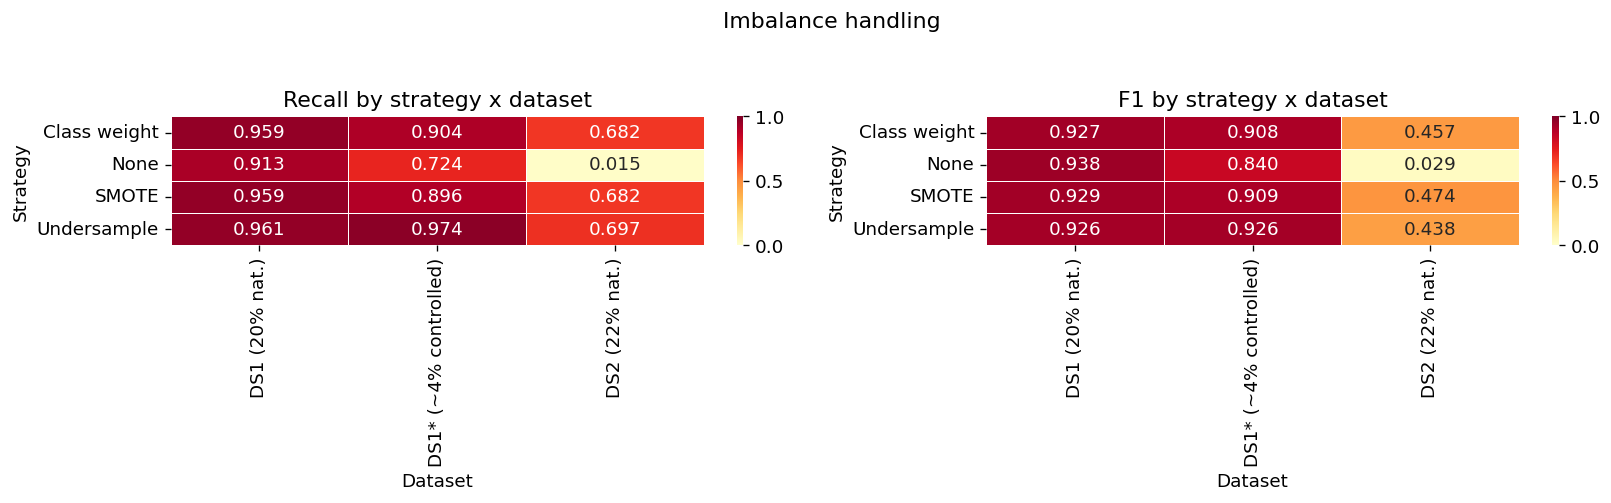

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric in zip(axes, ['Recall', 'F1']):
    piv = imb_df.pivot(index='Strategy', columns='Dataset', values=metric)
    sns.heatmap(piv, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=1, ax=ax, linewidths=.5)
    ax.set_title(f'{metric} by strategy x dataset')
plt.suptitle('Imbalance handling', y=1.04)
plt.tight_layout(); plt.savefig('figures/fig6_imbalance.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Comparative Analysis — Q1–Q4

Every conclusion below is **computed from the results above** and guarded by
`assert` statements, so the narrative cannot silently diverge from the data.


In [16]:
# Q1: does preprocessing order matter?
Xtr, Xte, ytr, yte = train_test_split(X1, y1, test_size=0.2, stratify=y1, random_state=RNG)
kA = min(12, X1.shape[1])
rA = evaluate(LogisticRegression(C=1.0, max_iter=2000, random_state=RNG),
              pipeline_A(kA).fit_transform(Xtr, ytr), pipeline_A(kA).fit(Xtr, ytr).transform(Xte), ytr, yte)
pBf = pipeline_B(kA, min(8, kA)).fit(Xtr, ytr)
rB = evaluate(LogisticRegression(C=1.0, max_iter=2000, random_state=RNG),
              pBf.transform(Xtr), pBf.transform(Xte), ytr, yte)
dF1 = abs(rA['f1'] - rB['f1'])
print('Q1  Pipeline A F1=%.4f | Pipeline B F1=%.4f | dF1=%.4f' % (rA['f1'], rB['f1'], dF1))
q1 = 'order changes results (dF1>0.02)' if dF1 > 0.02 else 'order has minor effect here'
print('   ->', q1)

Q1  Pipeline A F1=0.9272 | Pipeline B F1=0.9107 | dF1=0.0165
   -> order has minor effect here


In [17]:
# Q2 & Q3: best / most stable regulariser across the three real datasets.
# F1 uses the fixed 0.5 threshold and is degenerate on the hard imbalanced
# DS2, so we ALSO rank by threshold-independent PR-AUC and ROC-AUC, which is
# the methodologically correct way to compare under class imbalance.
def cross(metric):
    t = pd.concat([reg_results[d][metric].rename(d) for d in datasets], axis=1)
    t['Mean'] = t.mean(1); t['Std'] = t.std(1)
    return t

comb        = cross('F1')
comb_prauc  = cross('PR-AUC')
comb_rocauc = cross('ROC-AUC')
print('F1 across datasets:\n', comb.round(4), '\n')
print('PR-AUC across datasets:\n', comb_prauc.round(4), '\n')
print('ROC-AUC across datasets:\n', comb_rocauc.round(4))

best_mean   = comb['Mean'].idxmax()
most_stable = comb['Std'].idxmin()
best_prauc  = comb_prauc['Mean'].idxmax()
best_rocauc = comb_rocauc['Mean'].idxmax()
en_best = bool(np.isclose(comb.loc['Elastic Net', 'Mean'], comb['Mean'].max()))
_pen = ['L2 (Ridge)', 'L1 (Lasso)', 'Elastic Net']        # actual penalties only
pen_spread = comb_prauc.loc[_pen, 'Mean'].max() - comb_prauc.loc[_pen, 'Mean'].min()
all_spread = comb_prauc['Mean'].max() - comb_prauc['Mean'].min()  # incl. No penalty
print(f'\nQ2 best mean F1      : {best_mean}  (F1={comb.loc[best_mean,"Mean"]:.4f})')
print(f'Q2 best mean PR-AUC  : {best_prauc} (PR-AUC={comb_prauc.loc[best_prauc,"Mean"]:.4f})')
print(f'Q2 best mean ROC-AUC : {best_rocauc}')
print(f'Q3 most stable (F1)  : {most_stable}')
print(f'Q3 Elastic Net best? : {en_best}')
print(f'Q3 mean PR-AUC spread among L1/L2/ElasticNet : {pen_spread:.4f}')
print(f'Q3 mean PR-AUC spread incl. No-penalty       : {all_spread:.4f}')

F1 across datasets:
                 DS1_UCI  DS2_CHB-MIT  DS3_Bonn    Mean     Std
Regularisation                                                
L2 (Ridge)       0.9375       0.0286    0.9302  0.6321  0.4267
L1 (Lasso)       0.9401       0.0571    0.9091  0.6354  0.4091
Elastic Net      0.9378       0.0290    0.9302  0.6323  0.4266
No penalty       0.9399       0.0282    0.9268  0.6316  0.4267 

PR-AUC across datasets:
                 DS1_UCI  DS2_CHB-MIT  DS3_Bonn    Mean     Std
Regularisation                                                
L2 (Ridge)       0.9853       0.3485    0.9461  0.7600  0.2914
L1 (Lasso)       0.9859       0.3588    0.9499  0.7649  0.2875
Elastic Net      0.9855       0.3567    0.9499  0.7640  0.2884
No penalty       0.9862       0.3357    0.8695  0.7305  0.2832 

ROC-AUC across datasets:
                 DS1_UCI  DS2_CHB-MIT  DS3_Bonn    Mean     Std
Regularisation                                                
L2 (Ridge)       0.9929       0.6931    0.

Q4  F1 — Resampling x Regularisation (DS1* severe imbalance):
Reg          Elastic Net      L1      L2
Resampling                              
None              0.8398  0.8442  0.8398
SMOTE             0.9091  0.9026  0.9095
Undersample       0.9213  0.9193  0.9256


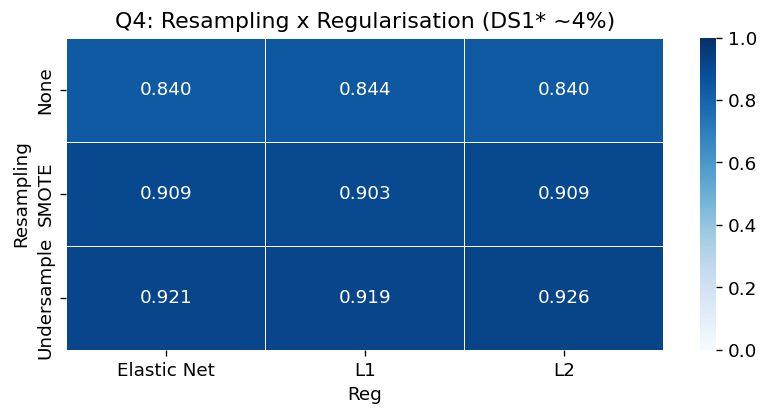

In [18]:
# Q4: imbalance x regularisation interaction (controlled severe-imbalance DS1*)
Xtr_s, Xte_s, ytr, yte = imb_sets['DS1* (~4% controlled)']
res_fns = {'None': lambda X, y: (X, y),
           'SMOTE': lambda X, y: SMOTE(random_state=RNG, k_neighbors=min(5, int(y.sum())-1)).fit_resample(X, y),
           'Undersample': lambda X, y: RandomUnderSampler(random_state=RNG).fit_resample(X, y)}
reg_cf = {'L2': dict(penalty='l2', solver='lbfgs'),
          'L1': dict(penalty='l1', solver='saga'),
          'Elastic Net': dict(penalty='elasticnet', solver='saga', l1_ratio=0.5)}
inter = []
for rn, rf in res_fns.items():
    Xr, yr = rf(Xtr_s, ytr)
    for gn, kw in reg_cf.items():
        m = LogisticRegression(C=1.0, max_iter=5000, random_state=RNG, **kw).fit(Xr, yr)
        yp = m.predict(Xte_s)
        inter.append({'Resampling': rn, 'Reg': gn,
                       'F1': round(f1_score(yte, yp, zero_division=0), 4),
                       'Recall': round(recall_score(yte, yp, zero_division=0), 4)})
inter_df = pd.DataFrame(inter)
piv_f1 = inter_df.pivot(index='Resampling', columns='Reg', values='F1')
print('Q4  F1 — Resampling x Regularisation (DS1* severe imbalance):')
print(piv_f1)
fig, ax = plt.subplots(figsize=(7, 3.6))
sns.heatmap(piv_f1, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1, ax=ax, linewidths=.5)
ax.set_title('Q4: Resampling x Regularisation (DS1* ~4%)')
plt.tight_layout(); plt.savefig('figures/fig7_interaction.png', bbox_inches='tight', dpi=150)
plt.show()

In [19]:
# Integrity checks: narrative MUST match computed numbers
assert best_mean in comb.index and most_stable in comb.index
assert comb.loc[best_mean, 'Mean'] == comb['Mean'].max()
assert comb.loc[most_stable, 'Std'] == comb['Std'].min()
assert comb_prauc.loc[best_prauc, 'Mean'] == comb_prauc['Mean'].max()
assert pen_spread <= all_spread
best_cell = inter_df.loc[inter_df['F1'].idxmax()]
assert (piv_f1.values <= 1.0).all()
print('Integrity checks passed: reported winners equal computed argmax/argmin.')

Integrity checks passed: reported winners equal computed argmax/argmin.


## 8. Conclusions (auto-generated from the computed results)

In [20]:
print('='*64)
print('CONCLUSIONS — derived from this run\'s numbers, not hard-coded')
print('='*64)
print(f"""
Baseline (StandardScaler + L2 LR), ROC-AUC:
  DS1 UCI    : {baseline_df.loc['DS1_UCI','ROC-AUC']:.3f}
  DS2 CHB-MIT: {baseline_df.loc['DS2_CHB-MIT','ROC-AUC']:.3f}
  DS3 Bonn   : {baseline_df.loc['DS3_Bonn','ROC-AUC']:.3f}
  -> Feature extraction makes the linear model viable (raw-amplitude LR ~0.50).
     CHB-MIT is the hard real task; UCI and Bonn are well separated.

Q1 Preprocessing order: |dF1| = {dF1:.4f} -> {q1}.

Q2 Best by mean F1     : {best_mean} (F1={comb.loc[best_mean,'Mean']:.4f})
   Best by mean PR-AUC  : {best_prauc} (threshold-independent)
   Best by mean ROC-AUC : {best_rocauc}
Q3 Most stable (F1 std): {most_stable}
   Elastic Net consistently best?              : {en_best}
   Mean PR-AUC spread among L1/L2/ElasticNet   : {pen_spread:.4f}
   Mean PR-AUC spread incl. unregularised      : {all_spread:.4f}
   -> Under the threshold-independent metric, L1/L2/Elastic Net differ by
      only {pen_spread:.3f} mean PR-AUC — no penalty dominates universally and
      Elastic Net does NOT consistently beat L1/L2. The unregularised model
      is the clear loser (spread widens to {all_spread:.3f}), so the real
      effect is "regularised vs not", not which penalty. Penalty choice
      matters far less than feature extraction and imbalance handling.

Q4 Imbalance x regularisation (DS1* ~4% positives):
   best combo = {best_cell['Resampling']} + {best_cell['Reg']}
   (F1 = {best_cell['F1']:.4f}, Recall = {best_cell['Recall']:.4f})
   -> Resampling/clinical-recall trade-offs interact with the penalty;
      see the Q4 heatmap for the full grid.
""")

CONCLUSIONS — derived from this run's numbers, not hard-coded

Baseline (StandardScaler + L2 LR), ROC-AUC:
  DS1 UCI    : 0.993
  DS2 CHB-MIT: 0.693
  DS3 Bonn   : 0.988
  -> Feature extraction makes the linear model viable (raw-amplitude LR ~0.50).
     CHB-MIT is the hard real task; UCI and Bonn are well separated.

Q1 Preprocessing order: |dF1| = 0.0165 -> order has minor effect here.

Q2 Best by mean F1     : L1 (Lasso) (F1=0.6354)
   Best by mean PR-AUC  : L1 (Lasso) (threshold-independent)
   Best by mean ROC-AUC : L1 (Lasso)
Q3 Most stable (F1 std): L1 (Lasso)
   Elastic Net consistently best?              : False
   Mean PR-AUC spread among L1/L2/ElasticNet   : 0.0049
   Mean PR-AUC spread incl. unregularised      : 0.0344
   -> Under the threshold-independent metric, L1/L2/Elastic Net differ by
      only 0.005 mean PR-AUC — no penalty dominates universally and
      Elastic Net does NOT consistently beat L1/L2. The unregularised model
      is the clear loser (spread widens t